In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images : (60000, 28, 28)
Testing Images : (10000, 28, 28)


In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [4]:
X_train = X_train.reshape(-1,28,28,1)
X_test  = X_test.reshape(-1,28,28,1)


In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [6]:
y_train_cat = to_categorical(y_train,10)
y_val_cat   = to_categorical(y_val,10)
y_test_cat  = to_categorical(y_test,10)

In [7]:
model = Sequential()


model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))


model.add(Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [9]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.8108 - loss: 0.5225 - val_accuracy: 0.8722 - val_loss: 0.3445
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.8744 - loss: 0.3479 - val_accuracy: 0.8834 - val_loss: 0.3158
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.8905 - loss: 0.2995 - val_accuracy: 0.8953 - val_loss: 0.2821
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.8998 - loss: 0.2709 - val_accuracy: 0.8981 - val_loss: 0.2754
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.9095 - loss: 0.2439 - val_accuracy: 0.9063 - val_loss: 0.2548
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 73s 21ms/step - accuracy: 0.9171 - loss: 0.2264 - val_accuracy: 0.9057 - val_loss: 0.2589
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9216 - loss: 0.2089 - val_accuracy: 0.9129 - val_loss: 0.2513
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.9288 -

In [10]:
loss, accuracy = model.evaluate(X_test, y_test_cat)
print("Test Accuracy =", accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9051 - loss: 0.2698
Test Accuracy = 0.9050999879837036


In [11]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [12]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1000
           1       0.99      0.98      0.99      1000
           2       0.86      0.84      0.85      1000
           3       0.93      0.89      0.91      1000
           4       0.84      0.85      0.85      1000
           5       0.98      0.98      0.98      1000
           6       0.72      0.73      0.72      1000
           7       0.93      0.98      0.96      1000
           8       0.98      0.97      0.98      1000
           9       0.99      0.94      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



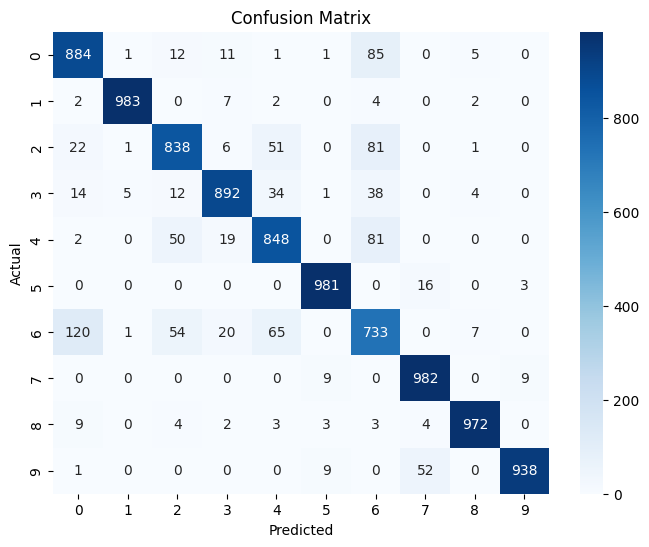

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


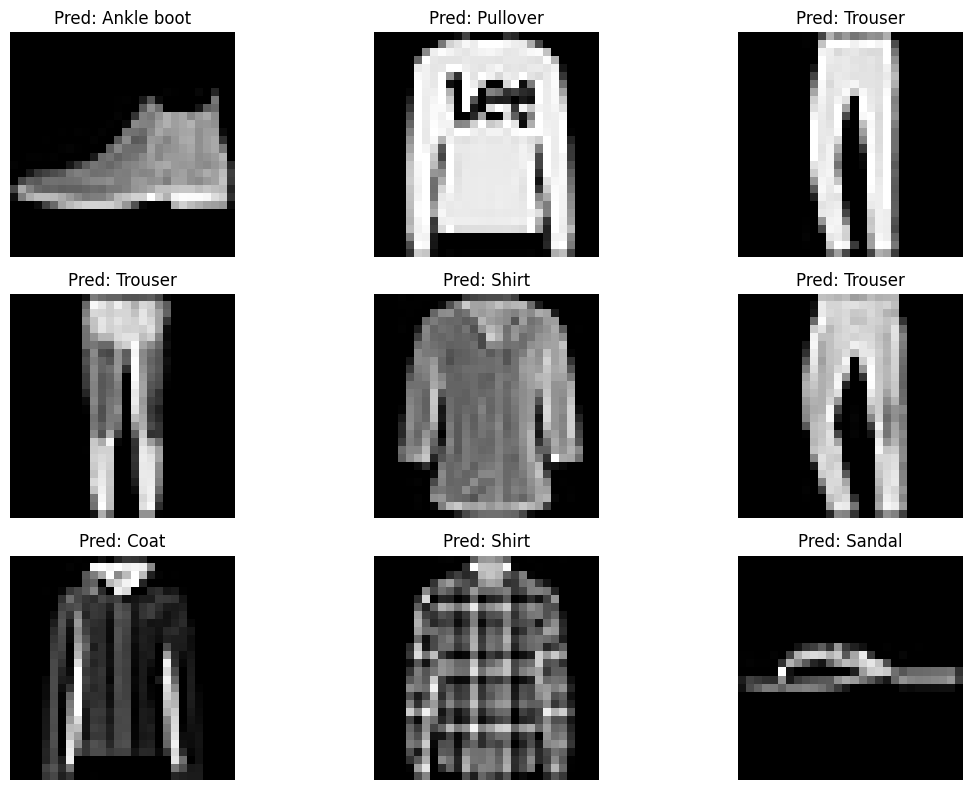

In [14]:
class_names = ['T-shirt','Trouser','Pullover','Dress',
               'Coat','Sandal','Shirt','Sneaker',
               'Bag','Ankle boot']

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title("Pred: " + class_names[y_pred[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

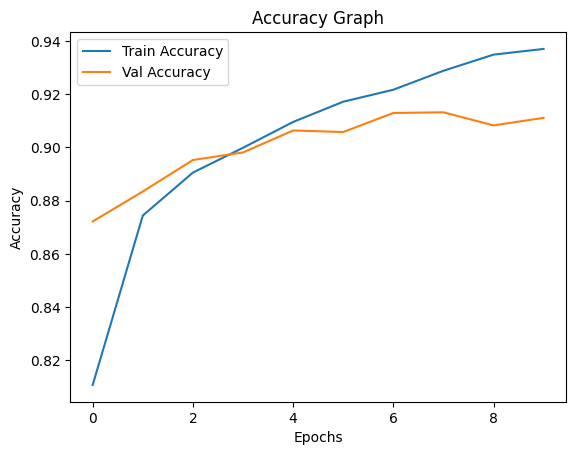

In [15]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

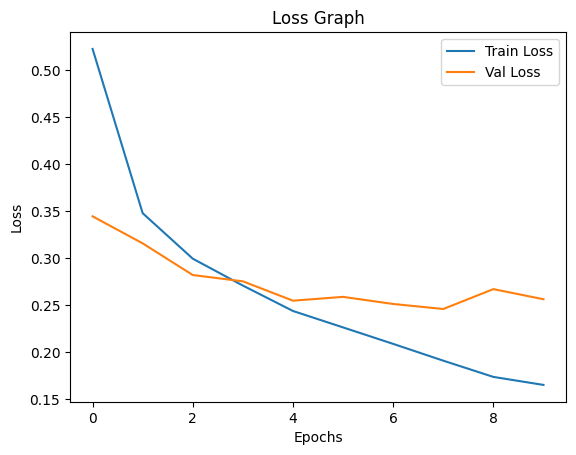

1. More filters improve feature learning.
2. Kernel size 3x3 commonly gives good result.
3. Dropout reduces overfitting.
4. If train accuracy high but val low = overfitting.
5. CNN better than simple ANN for images.


In [16]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()
print("1. More filters improve feature learning.")
print("2. Kernel size 3x3 commonly gives good result.")
print("3. Dropout reduces overfitting.")
print("4. If train accuracy high but val low = overfitting.")
print("5. CNN better than simple ANN for images.")